<a href="https://colab.research.google.com/github/patelparisha/ba820-b1-team10/blob/mILESTONES/BA820_M3_Team10.ipynb" target="_blank">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>


# BA820 — Milestone 3 Integrated Analysis (Team 10)

This notebook is the **team integration checkpoint** for Milestone 3.

It **reuses and unifies** the core M2 work into one reproducible pipeline:
- **Parisha**: Director-level casting profiles + collaboration concentration clusters  
- **Shanmathi**: Within-film “headline vs recurrence” movie-level features + clusters  
- **Inchara**: Historical “casting regimes” (era clustering) + Rule-of-7 (social norm) indicators  
- **Bhavya**: Couple-type **directionality** (older-man vs older-woman) and parity/inequality profiles  

We then run **three synergy tests** (integration experiments):

**Synergy A — Director ecosystems → within-film recurrence**  
**Synergy B — Historical eras → mechanism shifts (directionality, recurrence, violations)**  
**Synergy C — Headline vs non-headline couples → directionality + violations**.


In [1]:
# We install these once because a couple of our clustering visuals use them
!pip -q install yellowbrick plotly

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# We only use this for a quick dendrogram check in one section
from scipy.cluster.hierarchy import linkage, dendrogram

# Yellowbrick helps us visualize elbow + silhouette without writing a lot of extra plotting code
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

import plotly.express as px

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

RANDOM_STATE = 42  # we keep this fixed so our clustering results are reproducible

# We create output folders up front so later cells can save files/figures without errors
Path("data/derived").mkdir(parents=True, exist_ok=True)
Path("outputs").mkdir(parents=True, exist_ok=True)

print("Setup complete.")

Setup complete.


## 1) Load data + shared definitions

We load the Hollywood Age Gap dataset from the shared GitHub repo and define **shared thresholds** used across analyses.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv"
df_raw = pd.read_csv(DATA_URL)

# We use one "canonical" age gap column everywhere so later steps don't get messy
df_raw["age_gap"] = pd.to_numeric(df_raw["age_difference"], errors="coerce")

# We drop rows missing the core fields we rely on across the notebook
df = df_raw.dropna(subset=["movie_name", "release_year", "age_gap", "director"]).copy()
df["release_year"] = df["release_year"].astype(int)

# Shared definitions we reuse in merges/joins
movie_key = ["movie_name", "release_year"]

# Team thresholds (kept consistent across analyses)
large_gap_cutoff = 20
parity_cutoff = 3

# We build a consistent couple type label from the gender columns
g1 = df["character_1_gender"].astype(str).str.strip().str.lower()
g2 = df["character_2_gender"].astype(str).str.strip().str.lower()
df["pairing_type"] = g1 + "–" + g2

# Here we only care about directionality for mixed-gender pairs (older partner is listed first in this dataset)
df["directionality"] = np.where(
    df["pairing_type"].eq("man–woman"), "older_man",
    np.where(df["pairing_type"].eq("woman–man"), "older_woman", "other"))

df["is_large_gap"] = df["age_gap"] >= large_gap_cutoff
df["is_near_parity"] = df["age_gap"] <= parity_cutoff

# Decade bucket for time-trend comparisons
df["decade"] = (df["release_year"] // 10) * 10

df.shape, df.head(3)

((1155, 19),
            movie_name  release_year       director  age_difference  couple_number   actor_1_name     actor_2_name character_1_gender  \
 0    Harold and Maude          1971      Hal Ashby              52              1    Ruth Gordon         Bud Cort              woman   
 1               Venus          2006  Roger Michell              50              1  Peter O'Toole  Jodie Whittaker                man   
 2  The Quiet American          2002  Phillip Noyce              49              1  Michael Caine   Do Thi Hai Yen                man   
 
   character_2_gender actor_1_birthdate actor_2_birthdate  actor_1_age  actor_2_age  age_gap pairing_type directionality  is_large_gap  \
 0                man        1896-10-30        1948-03-29           75           23       52    woman–man    older_woman          True   
 1              woman        1932-08-02        1982-06-03           74           24       50    man–woman      older_man          True   
 2              woman  

### Quick coverage snapshot

This is not full EDA—just enough to sanity-check dataset coverage and skew.

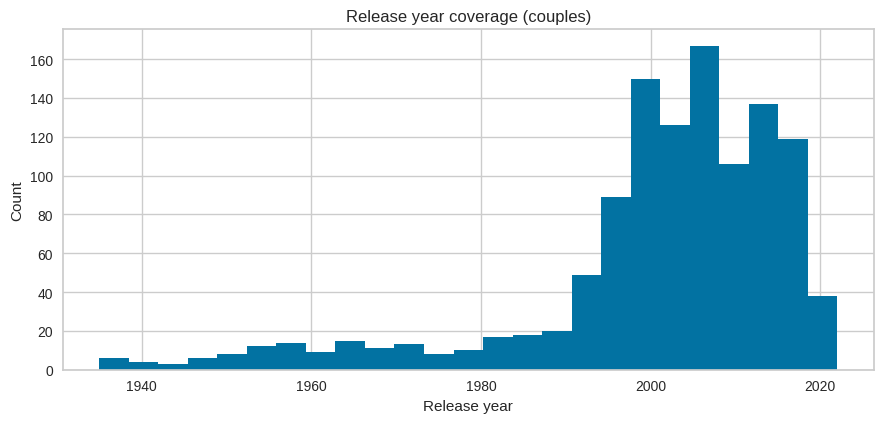

In [3]:
plt.figure(figsize=(9, 4.4))
plt.hist(df["release_year"], bins=25)
plt.title("Release year coverage (couples)")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

,count
pairing_type,
man–woman,929
woman–man,203
man–man,12
woman–woman,11


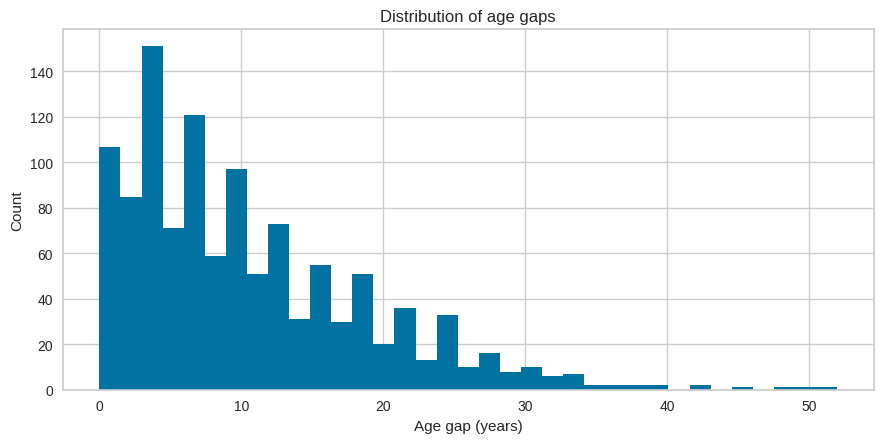

In [4]:
top_pairings = df["pairing_type"].value_counts().head(10)
display(top_pairings.rename("count").to_frame())

plt.figure(figsize=(9, 4.6))
plt.hist(df["age_gap"].dropna(), bins=35)
plt.title("Distribution of age gaps")
plt.xlabel("Age gap (years)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 2) Couple-level enrichment (Inchara + Bhavya baseline)

We create:
- **Rule-of-7** violation (social benchmark; Inchara)
- **Era clusters** (KMeans on standardized year + age gap; Inchara)
- Keep directionality/parity flags (Bhavya)

These will be re-used downstream for synergy tests and for merging to movie/director levels.

In [5]:
# "half your age + 7" benchmark + simple era clustering

# We use this as a quick benchmark to see how often the younger partner falls below the rule
df["older_age"] = df[["actor_1_age", "actor_2_age"]].max(axis=1)
df["younger_age"] = df[["actor_1_age", "actor_2_age"]].min(axis=1)

df["rule_threshold"] = df["older_age"] / 2 + 7
df["rule_violation"] = df["younger_age"] < df["rule_threshold"]

# We cluster movies into rough "eras" using just release_year and age_gap (scaled for KMeans)
era_data = df[["release_year", "age_gap"]].copy()
era_data = era_data.fillna(era_data.median(numeric_only=True))

era_scaled = StandardScaler().fit_transform(era_data)

k = 3
era_km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
df["era_cluster"] = era_km.fit_predict(era_scaled)

# We keep silhouette per row so we can spot points that don't fit their era well
df["era_silhouette"] = silhouette_samples(era_scaled, df["era_cluster"])

# We label clusters by sorting them by average year (so labels are interpretable)
era_summary = (
    df.groupby("era_cluster")
      .agg(
          start_year=("release_year", "min"),
          end_year=("release_year", "max"),
          avg_year=("release_year", "mean"),
          n=("release_year", "size"),)
      .sort_values("avg_year"))

In [6]:
ordered = era_summary.index.tolist()
era_names = {ordered[0]: "Classic", ordered[1]: "Transition", ordered[2]: "Modern"}
df["era_label"] = df["era_cluster"].map(era_names)

display(era_summary)
df[["movie_name", "release_year", "age_gap", "era_cluster", "era_label", "era_silhouette"]].head()

,start_year,end_year,avg_year,n
era_cluster,,,,
1,1935,1984,1961.968254,126
2,1971,2022,2004.720430,279
0,1982,2022,2005.864000,750


,movie_name,release_year,age_gap,era_cluster,era_label,era_silhouette
0,Harold and Maude,1971,52,2,Transition,0.058500
1,Venus,2006,50,2,Transition,0.311672
2,The Quiet American,2002,49,2,Transition,0.302833
3,The Big Lebowski,1998,45,2,Transition,0.318886
4,Beginners,2010,43,2,Transition,0.388721


### Rule-of-7 violations by decade (Inchara)

This is a compact version of Inchara’s benchmark view.

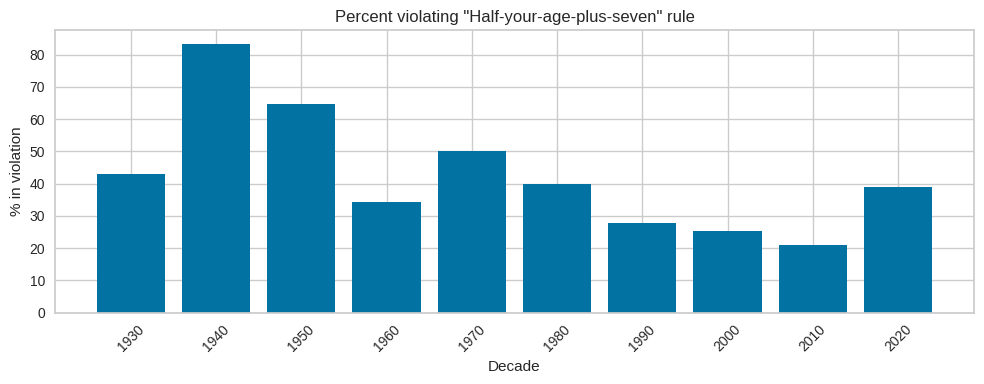

,decade,pct_violation
0,1930,42.857143
1,1940,83.333333
2,1950,64.705882
3,1960,34.285714
4,1970,50.000000
5,1980,40.000000
6,1990,27.927928
7,2000,25.427873
8,2010,21.005917
9,2020,38.888889


In [7]:
# Inchara calculated the % of couples that violate the rule in each decade
viol_by_decade = (
    df.groupby("decade")["rule_violation"]
      .mean()
      .mul(100)
      .reset_index(name="pct_violation")
      .sort_values("decade"))

plt.figure(figsize=(10, 4))
plt.bar(viol_by_decade["decade"].astype(str), viol_by_decade["pct_violation"])
plt.title('Percent violating "Half-your-age-plus-seven" rule')
plt.xlabel("Decade")
plt.ylabel("% in violation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(viol_by_decade.tail(10))

### Save enriched couple-level table

This becomes a shared input for M3 integration.

In [8]:
# We’re saving a cleaned/enriched couple-level file so the rest of the notebook can reuse it easily
cols = ["movie_name", "release_year", "director", "couple_number",
    "age_gap", "is_large_gap", "is_near_parity",
    "pairing_type", "directionality",
    "older_age", "younger_age", "rule_threshold", "rule_violation",
    "decade", "era_cluster", "era_label", "era_silhouette",
    "actor_1_name", "actor_2_name", "character_1_gender", "character_2_gender",
    "actor_1_age", "actor_2_age",]

couples_enriched = df[cols].copy()

out_file = Path("data/derived") / "couple_level_enriched.csv"
out_file.parent.mkdir(parents=True, exist_ok=True)
couples_enriched.to_csv(out_file, index=False)

couples_enriched.head()

,movie_name,release_year,director,couple_number,age_gap,is_large_gap,is_near_parity,pairing_type,directionality,older_age,younger_age,rule_threshold,rule_violation,decade,era_cluster,era_label,era_silhouette,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,1,52,True,False,woman–man,older_woman,75,23,44.5,True,1970,2,Transition,0.058500,Ruth Gordon,Bud Cort,woman,man,75,23
1,Venus,2006,Roger Michell,1,50,True,False,man–woman,older_man,74,24,44.0,True,2000,2,Transition,0.311672,Peter O'Toole,Jodie Whittaker,man,woman,74,24
2,The Quiet American,2002,Phillip Noyce,1,49,True,False,man–woman,older_man,69,20,41.5,True,2000,2,Transition,0.302833,Michael Caine,Do Thi Hai Yen,man,woman,69,20
3,The Big Lebowski,1998,Joel Coen,1,45,True,False,man–woman,older_man,68,23,41.0,True,1990,2,Transition,0.318886,David Huddleston,Tara Reid,man,woman,68,23
4,Beginners,2010,Mike Mills,1,43,True,False,man–man,other,81,38,47.5,True,2010,2,Transition,0.388721,Christopher Plummer,Goran Visnjic,man,man,81,38


## 3) Director-level profiles + clustering (Parisha)

We replicate Parisha’s director-level feature engineering:
- age-gap profile: `median_gap`, `gap_std`, `pct_large_gap`
- collaboration concentration (normalized): `max_actor_repeats_per_couple`, `unique_actors_per_link`

Then we cluster directors (KMeans with silhouette scan + size sanity check), and save `director_level_profiles.csv`.

In [9]:
# Parisha filtered out directors with too few couples so the stats aren’t just noise
dir_counts = df.groupby("director").size().sort_values(ascending=False)
min_couples = 5

keep_dirs = dir_counts[dir_counts >= min_couples].index
df_dir = df[df["director"].isin(keep_dirs)].copy()

print("Directors retained:", df_dir["director"].nunique())
print("Couples retained:", len(df_dir))

# Age-gap profile per director
age_profile = (
    df_dir.groupby("director")
    .agg(
        mean_gap=("age_gap", "mean"),
        median_gap=("age_gap", "median"),
        gap_std=("age_gap", "std"),
        num_couples=("age_gap", "size"),
        pct_large_gap=("is_large_gap", "mean"),)
    .reset_index())

Directors retained: 56
Couples retained: 387


In [10]:
# Parisha reshaped actors into a long format so we can count repeated collaborations cleanly
actors_long = pd.concat(
    [df_dir[["director", "actor_1_name"]].rename(columns={"actor_1_name": "actor"}),
      df_dir[["director", "actor_2_name"]].rename(columns={"actor_2_name": "actor"}),],
    ignore_index=True,
).dropna(subset=["actor"])

actor_counts = (
    actors_long.groupby(["director", "actor"])
    .size()
    .reset_index(name="collab_count")
)

collab_profile = (
    actor_counts.groupby("director")
    .agg(
        unique_actors=("actor", "nunique"),
        total_actor_links=("collab_count", "sum"),
        max_actor_repeats=("collab_count", "max"),
    )
    .reset_index()
)

director_eda = age_profile.merge(collab_profile, on="director", how="left")

director_eda["max_repeats_per_couple"] = director_eda["max_actor_repeats"] / director_eda["num_couples"]
director_eda["unique_actors_per_role"] = director_eda["unique_actors"] / (2 * director_eda["num_couples"])

director_eda.head()

,director,mean_gap,median_gap,gap_std,num_couples,pct_large_gap,unique_actors,total_actor_links,max_actor_repeats,max_repeats_per_couple,unique_actors_per_role
0,Adrian Lyne,12.833333,8.5,13.934370,6,0.333333,10,12,2,0.333333,0.833333
1,Alfred Hitchcock,21.000000,22.0,5.228129,7,0.857143,10,14,3,0.428571,0.714286
2,Andy Tennant,6.800000,6.0,3.114482,5,0.000000,9,10,2,0.400000,0.900000
3,Ang Lee,6.285714,2.0,10.242303,7,0.142857,12,14,2,0.285714,0.857143
4,"Bobby Farrelly, Peter Farrelly",7.800000,7.0,4.604346,5,0.000000,8,10,3,0.600000,0.800000


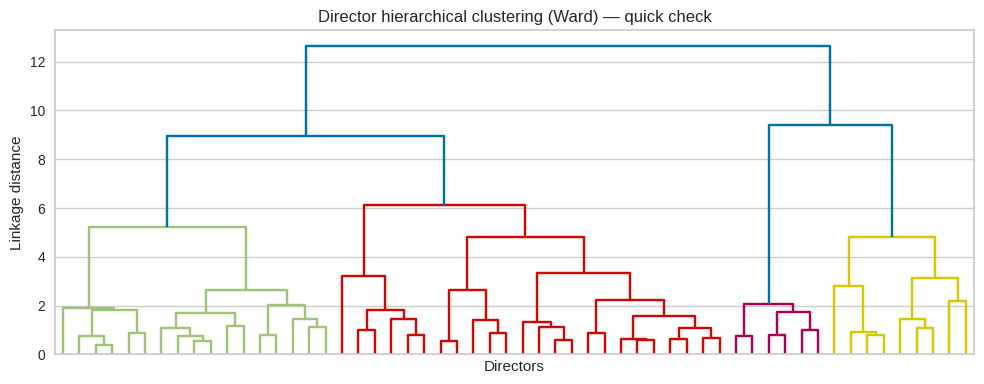

,k,silhouette,min_cluster_size,max_cluster_size
0,2,0.350731,16,40
1,3,0.351435,7,39
2,4,0.304834,7,25
3,5,0.299678,7,22
4,6,0.291978,7,13
5,7,0.283924,4,14


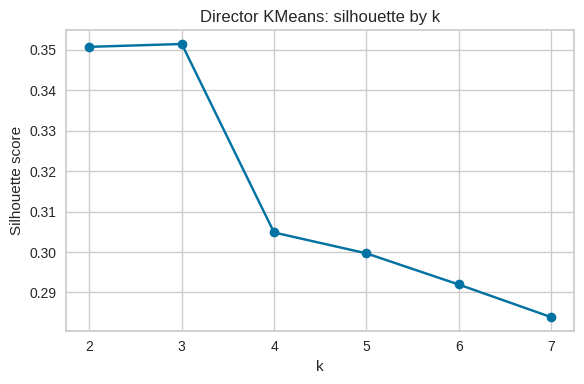

In [11]:
#  clustering directors using our combined 5-feature profile

# We’re clustering on a small feature set that mixes age-gap behavior + collaboration behavior
feat_cols = [
    "median_gap",
    "gap_std",
    "pct_large_gap",
    "max_repeats_per_couple",
    "unique_actors_per_role",
]

X = director_eda[feat_cols].copy()

# We fill missing values so clustering doesn't fail
X = X.fillna(X.median(numeric_only=True))

X_scaled = StandardScaler().fit_transform(X)

# We use a dendrogram as a quick sanity/robustness check
Z = linkage(X_scaled, method="ward")
plt.figure(figsize=(10, 4))
dendrogram(Z, no_labels=True)
plt.title("Director hierarchical clustering (Ward) — quick check")
plt.xlabel("Directors")
plt.ylabel("Linkage distance")
plt.tight_layout()
plt.show()

k_list = range(2, 8)
rows = []

for k in k_list:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)

    # we track cluster sizes because a “best” silhouette can come from tiny clusters
    sizes = pd.Series(labels).value_counts()
    rows.append(
        {
            "k": k,
            "silhouette": sil,
            "min_cluster_size": int(sizes.min()),
            "max_cluster_size": int(sizes.max()),
        }
    )

sil_df = pd.DataFrame(rows).sort_values("k")
display(sil_df)

plt.figure(figsize=(6, 4))
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.title("Director KMeans: silhouette by k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

In [12]:
# Choose k with a simple guardrail
best_k = int(sil_df.loc[sil_df["silhouette"].idxmax(), "k"])

# here we avoid choosing a k that creates very tiny clusters
min_size_ok = 4
ok_choices = sil_df[sil_df["min_cluster_size"] >= min_size_ok]

final_k = best_k
if len(ok_choices) > 0:
    final_k = int(ok_choices.loc[ok_choices["silhouette"].idxmax(), "k"])

print(f"Chosen k: {final_k} (best silhouette was k={best_k})")

kmeans_final = KMeans(n_clusters=final_k, random_state=RANDOM_STATE, n_init=25)
director_eda["director_cluster"] = kmeans_final.fit_predict(X_scaled)

cluster_summary = (
    director_eda.groupby("director_cluster")
    .agg(
        n_directors=("director", "count"),
        mean_median_gap=("median_gap", "mean"),
        mean_gap_std=("gap_std", "mean"),
        mean_pct_large_gap=("pct_large_gap", "mean"),
        mean_max_repeats=("max_repeats_per_couple", "mean"),
        mean_unique_actors=("unique_actors_per_role", "mean"),
        mean_num_couples=("num_couples", "mean"),
    )
    .round(3)
    .sort_index()
)

display(cluster_summary)

Chosen k: 3 (best silhouette was k=3)


,n_directors,mean_median_gap,mean_gap_std,mean_pct_large_gap,mean_max_repeats,mean_unique_actors,mean_num_couples
director_cluster,,,,,,,
0,39,6.949,7.438,0.123,0.320,0.857,6.385
1,10,10.550,6.877,0.063,0.703,0.659,6.900
2,7,19.857,7.945,0.537,0.477,0.680,9.857


### Save director-level table

In [13]:
# We’re saving the director-level table so we can reuse it later (and keep the workflow reproducible)
director_profiles = director_eda.copy()

out_file = Path("data/derived") / "director_level_profiles.csv"
director_profiles.to_csv(out_file, index=False)

director_profiles.head()

,director,mean_gap,median_gap,gap_std,num_couples,pct_large_gap,unique_actors,total_actor_links,max_actor_repeats,max_repeats_per_couple,unique_actors_per_role,director_cluster
0,Adrian Lyne,12.833333,8.5,13.934370,6,0.333333,10,12,2,0.333333,0.833333,0
1,Alfred Hitchcock,21.000000,22.0,5.228129,7,0.857143,10,14,3,0.428571,0.714286,2
2,Andy Tennant,6.800000,6.0,3.114482,5,0.000000,9,10,2,0.400000,0.900000,0
3,Ang Lee,6.285714,2.0,10.242303,7,0.142857,12,14,2,0.285714,0.857143,0
4,"Bobby Farrelly, Peter Farrelly",7.800000,7.0,4.604346,5,0.000000,8,10,3,0.600000,0.800000,1


## 4) Movie-level multi-couple features + clustering (Shanmathi)

We build the movie-level dataset for films with **2+ couples**, compute headline/recurrence features, then cluster into:
- Headline-dominant
- Recurrence-leaning
- Low-gap / typical

We also store the movie-level cluster label for integration.

In [14]:
# Recreate movie-level dataset (multi-couple films only)

movie_key = ["movie_name", "release_year"]
LARGE_GAP = 20

# Base summary per movie
movie_summary = (
    df.groupby(movie_key)
      .agg(
          n_couples=("age_gap", "size"),
          mean_gap=("age_gap", "mean"),
          median_gap=("age_gap", "median"),
          max_gap=("age_gap", "max"),
          count_large=("age_gap", lambda x: (x >= LARGE_GAP).sum()),
      )
      .reset_index()
)

# Keep only multi-couple movies
movie_summary = movie_summary[movie_summary["n_couples"] >= 2].copy()

# Compute top 2 gaps per movie
top2 = (
    df.groupby(movie_key)["age_gap"]
      .apply(lambda s: s.sort_values(ascending=False).head(2).tolist())
      .reset_index(name="top2_gaps")
)

top2[["max_gap", "second_gap"]] = pd.DataFrame(
    top2["top2_gaps"].tolist(),
    index=top2.index
)

top2["top_gap_dominance"] = top2["max_gap"] - top2["second_gap"]

top2 = top2[movie_key + ["second_gap", "top_gap_dominance"]]

# Merge into final clustering dataset
movie_m2 = movie_summary.merge(top2, on=movie_key, how="left")

print("Movie-level dataset ready for clustering:")
print(movie_m2.shape)
movie_m2.head()

Movie-level dataset ready for clustering:
(224, 9)


,movie_name,release_year,n_couples,mean_gap,median_gap,max_gap,count_large,second_gap,top_gap_dominance
0,10 Things I Hate About You,1999,2,1.0,1.0,2,0,0.0,2.0
1,27 Dresses,2008,2,7.5,7.5,10,0,5.0,5.0
2,A Happening of Monumental Proportions,2017,2,4.0,4.0,8,0,0.0,8.0
3,A Perfect Murder,1998,2,21.0,21.0,28,1,14.0,14.0
4,A Simple Favor,2018,2,1.0,1.0,2,0,0.0,2.0


In [15]:
movie_feats = ["top_gap_dominance", "second_gap", "median_gap", "count_large", "n_couples"]

# Drop rows with missing values so KMeans/silhouette don’t break
X_movie = movie_m2[movie_feats].dropna().copy()
movies_used = movie_m2.loc[X_movie.index].copy()

X_scaled = StandardScaler().fit_transform(X_movie)

k_vals = range(2, 9)
inertia = []
sil_scores = []

for k in k_vals:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

k_results = pd.DataFrame({"k": list(k_vals), "inertia": inertia, "silhouette": sil_scores})
display(k_results)

,k,inertia,silhouette
0,2,676.833175,0.471301
1,3,529.689082,0.463567
2,4,406.293654,0.411089
3,5,339.871121,0.422828
4,6,291.500361,0.336893
5,7,257.693629,0.321460
6,8,232.304439,0.327116


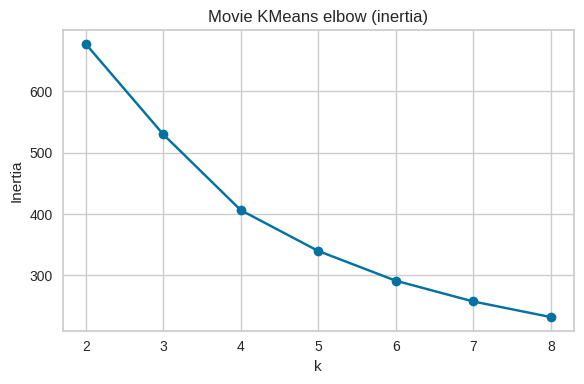

In [16]:
plt.figure(figsize=(6, 4))
plt.plot(k_results["k"], k_results["inertia"], marker="o")
plt.title("Movie KMeans elbow (inertia)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

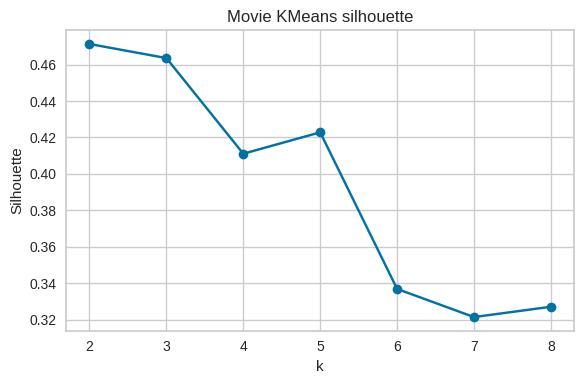

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(k_results["k"], k_results["silhouette"], marker="o")
plt.title("Movie KMeans silhouette")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.tight_layout()
plt.show()

In [18]:
# Stick with k=3 here because it matches the story and still looks reasonable in the metrics
k_final = 3
km_movie = KMeans(n_clusters=k_final, random_state=RANDOM_STATE, n_init=25)
movies_used["movie_cluster"] = km_movie.fit_predict(X_scaled)

# Median profiles are easier to interpret than means when a few movies are extreme
movie_cluster_profile = movies_used.groupby("movie_cluster")[movie_feats].median().round(2)
display(movie_cluster_profile)

# Name clusters based on the median profiles above
cluster_names = {
    0: "Headline-dominant",
    1: "Recurrence-leaning",
    2: "Low-gap / typical",
}
movies_used["movie_cluster_name"] = movies_used["movie_cluster"].map(cluster_names)

display(movies_used["movie_cluster_name"].value_counts())


,top_gap_dominance,second_gap,median_gap,count_large,n_couples
movie_cluster,,,,,
0,20.0,7.5,16.25,1.0,2.0
1,4.0,4.0,6.50,0.0,2.0
2,5.0,18.0,20.00,1.0,3.0


,count
movie_cluster_name,
Recurrence-leaning,163
Headline-dominant,36
Low-gap / typical,25


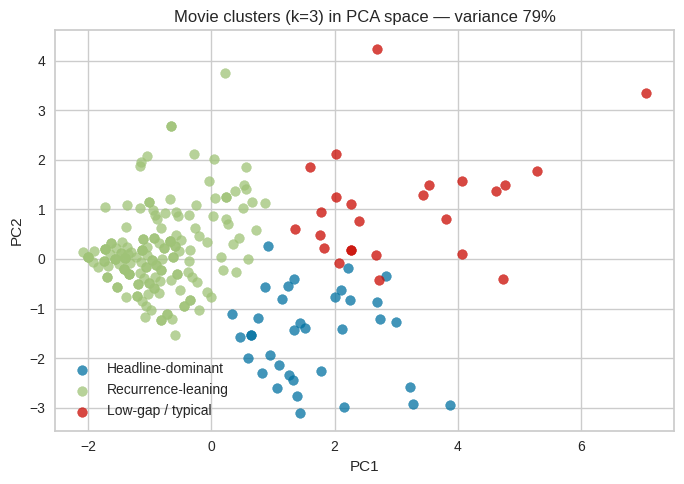

In [19]:
# PCA view of the movie clusters

pca = PCA(n_components=2, random_state=RANDOM_STATE)
movie_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

for c in sorted(movies_used["movie_cluster"].unique()):
    mask = movies_used["movie_cluster"].values == c
    label = cluster_names.get(c, f"Cluster {c}")
    plt.scatter(movie_pca[mask, 0], movie_pca[mask, 1], alpha=0.75, label=label)

var_explained = pca.explained_variance_ratio_.sum()
plt.title(f"Movie clusters (k={k_final}) in PCA space — variance {var_explained:.0%}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.show()

### Save movie-level multi-couple table

In [20]:
# We’re saving the movie-level clustering output so we can reuse it in later sections / the write-up
movie_multicouple = movies_used.copy()

out_file = Path("data/derived") / "movie_level_multicouple.csv"
out_file.parent.mkdir(parents=True, exist_ok=True)
movie_multicouple.to_csv(out_file, index=False)

movie_multicouple.head()

,movie_name,release_year,n_couples,mean_gap,median_gap,max_gap,count_large,second_gap,top_gap_dominance,movie_cluster,movie_cluster_name
0,10 Things I Hate About You,1999,2,1.0,1.0,2,0,0.0,2.0,1,Recurrence-leaning
1,27 Dresses,2008,2,7.5,7.5,10,0,5.0,5.0,1,Recurrence-leaning
2,A Happening of Monumental Proportions,2017,2,4.0,4.0,8,0,0.0,8.0,1,Recurrence-leaning
3,A Perfect Murder,1998,2,21.0,21.0,28,1,14.0,14.0,0,Headline-dominant
4,A Simple Favor,2018,2,1.0,1.0,2,0,0.0,2.0,1,Recurrence-leaning


# 5) Integrated Synergy Story (Team Integration)

This section is the **integration checkpoint** for Milestone 3.  
Each synergy below explicitly **reuses artifacts from multiple M2 submissions** (features, assumptions, or models) and shows what we learned when we combined them.

**Storyline:**  
**(1)** *Macro* — historical casting regimes and norm shifts →  
**(2)** *Within-film packaging* — headline vs recurrence →  
**(3)** *Ecosystems* — director collaboration structures →  
**(4)** *Mechanism test* — is headline dominance actually “star bias”?


## 5.1 Synergy 1 — Historical casting regimes → directionality + norm violations  
**Primary M2 sources integrated:**  
- **Inchara**: era clustering (“casting regimes”) + silhouette logic  
- **Bhavya**: directionality framing (older-man vs older-woman)  
- **Inchara**: rule-of-seven violation flag

**Question:** Do era-level “regimes” correspond to measurable shifts in (a) who is older in couples and (b) social-norm violations?  
**Inputs reused:** `era_cluster/era_label`, `directionality`, `rule_violation`  
**Method:** Summarize couple-level and movie-level metrics by regime.  
**Outcome + learning:** Regimes are not just time bins — they align with meaningful shifts in inequality patterns and violations.


In [21]:
from pathlib import Path

# Read directly from memory (already-loaded DataFrames)
couples = couples_enriched
movies_multi = movie_multicouple

In [22]:
# 1) Couple-level summary by era

era_couple = (
    couples.groupby("era_label")
    .agg(
        n_couples=("age_gap", "size"),
        pct_large_gap=("is_large_gap", "mean"),
        pct_rule_violation=("rule_violation", "mean"),
        pct_near_parity=("is_near_parity", "mean"),
        pct_older_man=("directionality", lambda s: (s == "older_man").mean()),
        pct_older_woman=("directionality", lambda s: (s == "older_woman").mean()),
        mean_age_gap=("age_gap", "mean"),
    )
    .reset_index()
)

pct_cols = ["pct_large_gap", "pct_rule_violation", "pct_near_parity", "pct_older_man", "pct_older_woman"]
era_couple[pct_cols] = (era_couple[pct_cols] * 100).round(1)
era_couple["mean_age_gap"] = era_couple["mean_age_gap"].round(2)

display(era_couple)

,era_label,n_couples,pct_large_gap,pct_rule_violation,pct_near_parity,pct_older_man,pct_older_woman,mean_age_gap
0,Classic,126,33.3,50.8,7.9,93.7,6.3,14.64
1,Modern,750,0.0,7.7,35.6,74.3,24.0,5.72
2,Transition,279,47.0,73.1,0.0,91.0,5.4,21.16


In [23]:
# 2) Movie-level recurrence by era

mk = movie_key

# We assign each movie an era based on the most common era among its couples
movie_era = (
    couples.groupby(mk)["era_label"]
    .agg(lambda s: s.value_counts().idxmax())
    .reset_index(name="movie_era")
)

movies_by_era = movies_multi.merge(movie_era, on=mk, how="left")

era_movie_summary = (
    movies_by_era.groupby("movie_era")
    .agg(
        n_movies=("movie_name", "count"),
        pct_recurrence=("movie_cluster_name", lambda s: (s == "Recurrence-leaning").mean()),
        pct_headline_dom=("movie_cluster_name", lambda s: (s == "Headline-dominant").mean()),
        mean_dominance=("top_gap_dominance", "mean"),
        mean_second_gap=("second_gap", "mean"),
        pct_second_large=("second_gap", lambda s: (s >= LARGE_GAP).mean()),
    )
    .reset_index()
)

pct_cols2 = ["pct_recurrence", "pct_headline_dom", "pct_second_large"]
era_movie_summary[pct_cols2] = (era_movie_summary[pct_cols2] * 100).round(1)
era_movie_summary["mean_dominance"] = era_movie_summary["mean_dominance"].round(2)
era_movie_summary["mean_second_gap"] = era_movie_summary["mean_second_gap"].round(2)

display(era_movie_summary)

,movie_era,n_movies,pct_recurrence,pct_headline_dom,mean_dominance,mean_second_gap,pct_second_large
0,Classic,18,55.6,22.2,6.50,10.67,16.7
1,Modern,132,95.5,3.0,5.08,4.75,0.0
2,Transition,74,36.5,37.8,13.68,10.36,9.5


In [24]:
# 3) Director cluster composition by era

# Director clusters (assumed to exist)
dir_clusters = director_profiles[["director", "director_cluster"]].drop_duplicates()

# Label a director's era using the median year of their couples
dir_years = (
    df_dir.groupby("director")["release_year"]
    .median()
    .reset_index(name="median_year")
)

# Build era cutoffs from couple-level era labels (sorted by mean year)
era_cut = (
    df.groupby("era_label")["release_year"]
    .agg(avg_year="mean", end_year="max")
    .sort_values("avg_year")
    .reset_index()
)

cutoffs = era_cut["end_year"].tolist()

def era_from_year(y):
    if y <= cutoffs[0]:
        return era_cut.loc[0, "era_label"]
    if y <= cutoffs[1]:
        return era_cut.loc[1, "era_label"]
    return era_cut.loc[2, "era_label"]

dir_years["era_label_director"] = dir_years["median_year"].apply(era_from_year)

dir_years = dir_years.merge(dir_clusters, on="director", how="left")

dir_era_comp = (
    dir_years.groupby(["era_label_director", "director_cluster"])
    .size()
    .reset_index(name="n_directors")
    .sort_values(["era_label_director", "n_directors"], ascending=[True, False])
)

display(dir_era_comp.head(30))

,era_label_director,director_cluster,n_directors
2,Classic,2,4
0,Classic,0,1
1,Classic,1,1
3,Transition,0,38
4,Transition,1,9
5,Transition,2,3


## 5.2 Synergy 2 — Within-film packaging: headline vs non-headline couples  
**Primary M2 sources integrated:**  
- **Shanmathi**: headline / recurrence framing (multi-couple films)  
- **Bhavya**: directionality as core inequality signal  
- **Inchara**: rule-of-seven violations as social benchmark

**Question:** Are extreme age gaps mostly “packaged” into one standout couple (headline), and does that headline couple carry higher norm-violation risk?  
**Inputs reused:** `movie_level_multicouple`, headline flags (`is_headline_couple`), `directionality`, `rule_violation`  
**Method:** Flag one headline couple per film and compare headline vs non-headline distributions.  
**Outcome + learning:** Headline vs non-headline is a meaningful within-film distinction that connects narrative packaging to inequality risk.


In [25]:
# Making sure we have the couple-level table loaded
# Marking the "headline" couple in each movie as the one with the largest age gap
max_gap_by_movie = (
    couples.groupby(movie_key)["age_gap"]
    .max()
    .reset_index(name="movie_max_gap")
)

synC = couples.merge(max_gap_by_movie, on=movie_key, how="left")
synC["is_headline_couple"] = synC["age_gap"] == synC["movie_max_gap"]

# quick comparison: headline couples vs everyone else
headline_summary = (
    synC.groupby("is_headline_couple")
    .agg(
        n_couples=("age_gap", "size"),
        pct_large_gap=("is_large_gap", "mean"),
        pct_rule_violation=("rule_violation", "mean"),
        pct_near_parity=("is_near_parity", "mean"),
        pct_older_man=("directionality", lambda s: (s == "older_man").mean()),
        pct_older_woman=("directionality", lambda s: (s == "older_woman").mean()),
        mean_age_gap=("age_gap", "mean"),
    )
    .reset_index()
    .rename(columns={"is_headline_couple": "headline_flag"})
)

,headline_flag,n_couples,pct_large_gap,pct_rule_violation,pct_near_parity,pct_older_man,pct_older_woman,mean_age_gap
0,False,307,4.6,13.0,40.4,72.6,25.1,6.72
1,True,848,18.8,33.7,18.0,83.3,14.9,11.76


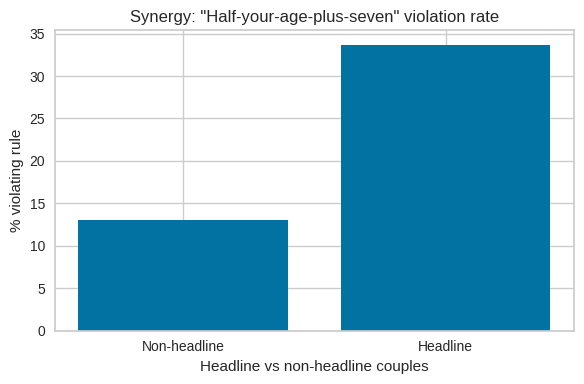

In [26]:
# Formatting the rates as percentages so the table is easier to read
pct_cols = ["pct_large_gap", "pct_rule_violation", "pct_near_parity", "pct_older_man", "pct_older_woman"]
headline_summary[pct_cols] = (headline_summary[pct_cols] * 100).round(1)
headline_summary["mean_age_gap"] = headline_summary["mean_age_gap"].round(2)

display(headline_summary)

# simple visual: rule violation rate for headline vs non-headline couples
labels = ["Non-headline", "Headline"]
vals = [
    headline_summary.loc[headline_summary["headline_flag"] == False, "pct_rule_violation"].iloc[0],
    headline_summary.loc[headline_summary["headline_flag"] == True, "pct_rule_violation"].iloc[0],
]

plt.figure(figsize=(6, 4))
plt.bar(labels, vals)
plt.title('Synergy: "Half-your-age-plus-seven" violation rate')
plt.xlabel("Headline vs non-headline couples")
plt.ylabel("% violating rule")
plt.tight_layout()
plt.show()


## 5.3 Synergy 3 — Director ecosystems → recurrence / dominance patterns (cross-unit integration)  
**Primary M2 sources integrated:**  
- **Parisha**: director clusters using age-gap + collaboration concentration (ecosystems)  
- **Shanmathi**: movie-level recurrence/dominance structure in multi-couple films

**Question:** Do stable **director ecosystems** align with within-film packaging patterns (recurrence vs headline dominance)?  
**Inputs reused:** `director_level_profiles (director_cluster)`, `movie_level_multicouple`  
**Method:** Join director clusters onto multi-couple movie table and compare recurrence/structure by director cluster.  
**Outcome + learning:** This links “who makes the films” (ecosystems) to “how inequality is packaged within films,” moving from description to structure.


In [27]:
movies = movies_multi

# Recreate movie -> director mapping
movie_director = (
    couples.groupby(["movie_name", "release_year"])["director"]
    .agg(lambda s: s.mode().iloc[0])   # most common director per movie
    .reset_index()
)

# Merge director into movie-level table
movies = movies.merge(
    movie_director,
    on=["movie_name", "release_year"],
    how="left"
)

# Same idea for the director cluster table (name varies a bit across our notebook versions)
dir_tbl = director_profiles

# director + cluster label for this merge
dir_clusters = dir_tbl[["director", "director_cluster"]].drop_duplicates()

synA = movies.merge(dir_clusters, on="director", how="left")

coverage = synA["director_cluster"].notna().mean()
print("Movies with director cluster available:", round(coverage, 3))

LARGE_GAP = 20

# Boolean flag for second gap
synA["second_is_large"] = synA["second_gap"] >= LARGE_GAP

# Headline share = max_gap relative to total gap mass
synA["headline_share"] = synA["max_gap"] / (
    synA["mean_gap"] * synA["n_couples"]
)

# Compare recurrence/dominance patterns across director clusters ---
synA_summary = (
    synA.groupby("director_cluster")
    .agg(
        n_movies=("movie_name", "count"),
        pct_recurrence=("movie_cluster_name", lambda s: (s == "Recurrence-leaning").mean()),
        mean_second_gap=("second_gap", "mean"),
        pct_second_large=("second_is_large", "mean"),
        mean_dominance=("top_gap_dominance", "mean"),
        mean_headline_share=("headline_share", "mean"),
    )
    .reset_index()
    .sort_values("n_movies", ascending=False)
)

Movies with director cluster available: 0.397


,director_cluster,n_movies,pct_recurrence,mean_second_gap,pct_second_large,mean_dominance,mean_headline_share
0,0.0,55,74.5,5.89,1.8,9.75,0.684
2,2.0,18,22.2,16.89,38.9,8.00,0.516
1,1.0,16,87.5,6.25,0.0,8.50,0.672


/tmp/ipython-input-1059223852.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(int(c)) for c in clusters])


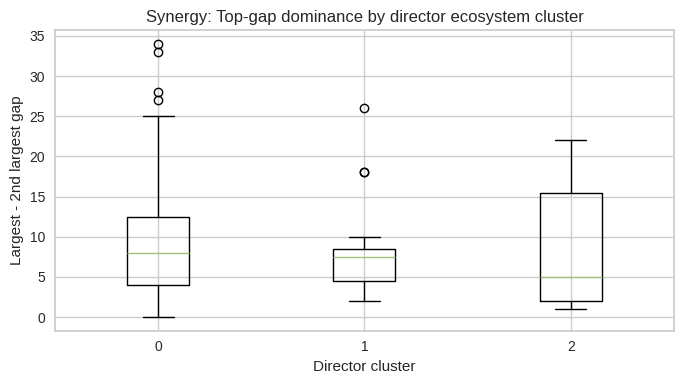

In [28]:
# formatting (makes it easier to read in the report)
synA_summary["pct_recurrence"] = (synA_summary["pct_recurrence"] * 100).round(1)
synA_summary["pct_second_large"] = (synA_summary["pct_second_large"] * 100).round(1)
synA_summary["mean_second_gap"] = synA_summary["mean_second_gap"].round(2)
synA_summary["mean_dominance"] = synA_summary["mean_dominance"].round(2)
synA_summary["mean_headline_share"] = synA_summary["mean_headline_share"].round(3)

display(synA_summary)

# Simple plot: dominance by director cluster
clusters = sorted(synA["director_cluster"].dropna().unique())

if len(clusters) == 0:
    print("No director clusters available to plot (most likely because the director filter removed them).")
else:
    data = [
        synA.loc[synA["director_cluster"] == c, "top_gap_dominance"].dropna().values
        for c in clusters
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=[str(int(c)) for c in clusters])
    plt.title("Synergy: Top-gap dominance by director ecosystem cluster")
    plt.xlabel("Director cluster")
    plt.ylabel("Largest - 2nd largest gap")
    plt.tight_layout()
    plt.show()

## 5.4 Synergy 4 — Mechanism test: is headline dominance actually “star bias”?  
**Primary M2 sources integrated:**  
- **Bhavya**: actor-recurrence star proxy  
- **Shanmathi**: headline dominance & multi-couple movie clustering  
- **Inchara**: era labels / rule violations as context

**Question:** If headline dominance reflects “star privilege,” do headline-dominant movies have more star-heavy headline couples?  
**Inputs reused:** `synC` (headline flags), `movie_level_multicouple` (dominance & clusters), `couple_level_enriched` (actor names)  
**Method:** Build star proxy from actor recurrence; extract one headline couple per movie; test correlation + group differences.  
**Outcome + learning:** Even a *null/weak* result is valuable: it differentiates narrative packaging from star-driven privilege under our proxy.


In [29]:
from pathlib import Path
from scipy.stats import spearmanr, mannwhitneyu

In [30]:
#  1) make sure we have the headline flag
if "synC" in globals():
    synD = synC.copy()
else:
    max_gap = couples.groupby(mk)["age_gap"].max().reset_index(name="movie_max_gap")
    synD = couples.merge(max_gap, on=mk, how="left")
    synD["is_headline_couple"] = synD["age_gap"] == synD["movie_max_gap"]

needed_cols = ["actor_1_name", "actor_2_name", "age_gap", "is_headline_couple", "rule_violation", "directionality", "era_label"]

In [31]:
#  2) simple "star proxy": how often the actors appear in the dataset
actor_counts = pd.concat(
    [couples["actor_1_name"], couples["actor_2_name"]],
    ignore_index=True
).dropna().value_counts()

synD["older_actor_freq"] = synD["actor_1_name"].map(actor_counts).fillna(0).astype(int)
synD["younger_actor_freq"] = synD["actor_2_name"].map(actor_counts).fillna(0).astype(int)

synD["headline_star_proxy"] = synD[["older_actor_freq", "younger_actor_freq"]].max(axis=1)

In [32]:
# 3) keep exactly one headline couple per movie
headline_one = (
    synD[synD["is_headline_couple"]]
      .sort_values(["age_gap", "headline_star_proxy"], ascending=[False, False])
      .groupby(mk, as_index=False)
      .head(1)
      .copy()
)

headline_one = headline_one[
    mk + ["headline_star_proxy", "older_actor_freq", "younger_actor_freq",
          "directionality", "rule_violation", "age_gap", "era_label"]
].rename(columns={"age_gap": "headline_age_gap"})

print("Headline couples extracted:", len(headline_one))

Headline couples extracted: 838


In [33]:
# 4) merge headline info onto the movie-level table ---
star_df = movies.merge(headline_one, on=mk, how="left").dropna(subset=["headline_star_proxy"]).copy()

# Recreate headline_share at movie level
star_df["headline_share"] = (
    star_df["max_gap"] /
    (star_df["mean_gap"] * star_df["n_couples"])
)

# 5) summarize star proxy by movie cluster (this matches our M2 narrative labels) ---
cluster_star_summary = (
    star_df.groupby("movie_cluster_name")
    .agg(
        n_movies=("movie_name", "count"),
        median_star=("headline_star_proxy", "median"),
        mean_star=("headline_star_proxy", "mean"),
        median_dominance=("top_gap_dominance", "median"),
        median_headline_share=("headline_share", "median"),
        pct_headline_rule_violation=("rule_violation", "mean"),
        pct_headline_older_man=("directionality", lambda s: (s == "older_man").mean()),
    )
    .reset_index()
    .sort_values("n_movies", ascending=False)
)

cluster_star_summary["mean_star"] = cluster_star_summary["mean_star"].round(2)
cluster_star_summary["median_dominance"] = cluster_star_summary["median_dominance"].round(2)
cluster_star_summary["median_headline_share"] = cluster_star_summary["median_headline_share"].round(3)
cluster_star_summary["pct_headline_rule_violation"] = (cluster_star_summary["pct_headline_rule_violation"] * 100).round(1)
cluster_star_summary["pct_headline_older_man"] = (cluster_star_summary["pct_headline_older_man"] * 100).round(1)

display(cluster_star_summary)

# optional test: headline-dominant vs others (only if we have enough movies to make it meaningful)
hd = star_df.loc[star_df["movie_cluster_name"] == "Headline-dominant", "headline_star_proxy"]
other = star_df.loc[star_df["movie_cluster_name"] != "Headline-dominant", "headline_star_proxy"]

if len(hd) > 10 and len(other) > 10:
    u_stat, p_val = mannwhitneyu(hd, other, alternative="two-sided")
    print(f"Mann–Whitney (Headline-dominant vs others): p = {p_val:.4g}")

,movie_cluster_name,n_movies,median_star,mean_star,median_dominance,median_headline_share,pct_headline_rule_violation,pct_headline_older_man
2,Recurrence-leaning,163,6.0,7.22,4.0,0.655,31.9,81.6
0,Headline-dominant,36,6.0,7.22,20.0,0.782,94.4,91.7
1,Low-gap / typical,25,8.0,10.24,5.0,0.469,96.0,92.0


Mann–Whitney (Headline-dominant vs others): p = 0.9618


Spearman(top_gap_dominance, star_proxy): rho=-0.005, p=0.9416
Spearman(headline_share, star_proxy):     rho=-0.063, p=0.3457


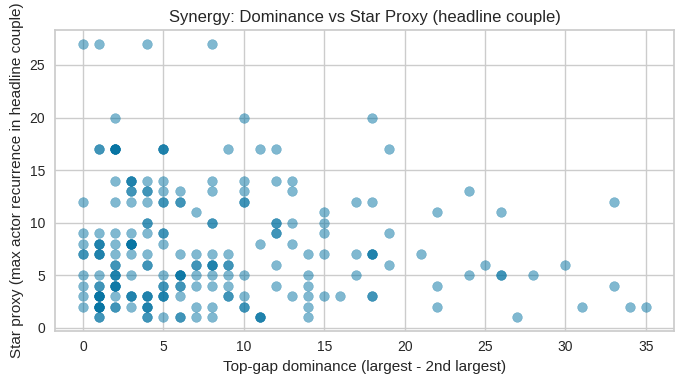

In [34]:
# 6) correlation: does dominance track the star proxy? ---
rho_dom, p_dom = spearmanr(star_df["top_gap_dominance"], star_df["headline_star_proxy"])
rho_share, p_share = spearmanr(star_df["headline_share"], star_df["headline_star_proxy"])

print(f"Spearman(top_gap_dominance, star_proxy): rho={rho_dom:.3f}, p={p_dom:.4g}")
print(f"Spearman(headline_share, star_proxy):     rho={rho_share:.3f}, p={p_share:.4g}")

# 7) quick visuals (kept simple on purpose) ---
plt.figure(figsize=(7, 4))
plt.scatter(star_df["top_gap_dominance"], star_df["headline_star_proxy"], alpha=0.5)
plt.title("Synergy: Dominance vs Star Proxy (headline couple)")
plt.xlabel("Top-gap dominance (largest - 2nd largest)")
plt.ylabel("Star proxy (max actor recurrence in headline couple)")
plt.tight_layout()
plt.show()

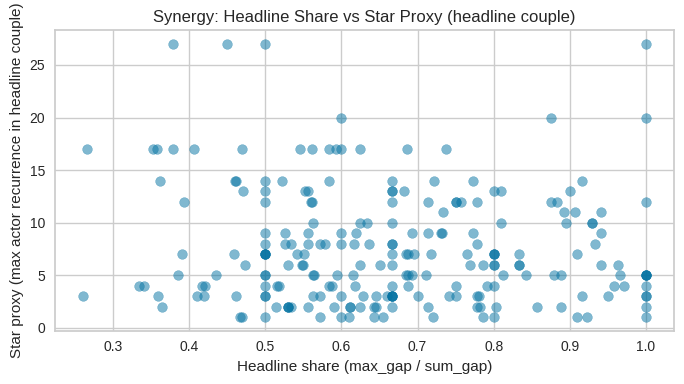

In [35]:
plt.figure(figsize=(7, 4))
plt.scatter(star_df["headline_share"], star_df["headline_star_proxy"], alpha=0.5)
plt.title("Synergy: Headline Share vs Star Proxy (headline couple)")
plt.xlabel("Headline share (max_gap / sum_gap)")
plt.ylabel("Star proxy (max actor recurrence in headline couple)")
plt.tight_layout()
plt.show()

In [36]:
# --- 8) save outputs (so the results are reproducible outside the notebook) ---
Path("outputs").mkdir(parents=True, exist_ok=True)
cluster_star_summary.to_csv("outputs/synergyD_starproxy_by_movie_cluster.csv", index=False)
star_df.to_csv("outputs/synergyD_starproxy_movie_level.csv", index=False)

# keep a named object in case we reuse this later
synD_star = star_df.copy()

# compact check table (same idea as our other sanity tables)
check = (
    synD_star.groupby("movie_cluster_name")
    .agg(
        n_movies=("movie_name", "nunique"),
        mean_headline_gap=("headline_age_gap", "mean"),
        median_headline_gap=("headline_age_gap", "median"),
        mean_max_gap=("max_gap", "mean"),
        median_max_gap=("max_gap", "median"),
        mean_second_gap=("second_gap", "mean"),
        median_second_gap=("second_gap", "median"),
        mean_dominance=("top_gap_dominance", "mean"),
        median_dominance=("top_gap_dominance", "median"),
        mean_headline_share=("headline_share", "mean"),
        median_headline_share=("headline_share", "median"),
        median_star=("headline_star_proxy", "median"),
    )
    .round(3)
    .sort_values("median_dominance", ascending=False)
)

display(check)

,n_movies,mean_headline_gap,median_headline_gap,mean_max_gap,median_max_gap,mean_second_gap,median_second_gap,mean_dominance,median_dominance,mean_headline_share,median_headline_share,median_star
movie_cluster_name,,,,,,,,,,,,
Headline-dominant,36,29.250,28.5,29.250,28.5,7.833,7.5,21.417,20.0,0.790,0.782,6.0
Low-gap / typical,25,25.600,24.0,25.600,24.0,19.240,18.0,6.360,5.0,0.473,0.469,8.0
Recurrence-leaning,163,10.387,10.0,10.387,10.0,5.049,4.0,5.337,4.0,0.667,0.655,6.0


## 5.5 Integration attempts not prioritized in the main storyline (documented effort)

These were explored as additional synergies, but we **did not keep them as the core four** to maintain a clean narrative and avoid overfitting / fragile results. They remain valid “integration effort” evidence for M3:

1) **Competing inequality metric scoreboard** *(team integration; originally “Synergy D — Competing Measures”)*  
   - Compared multiple inequality metrics (mean/median gap, large-gap share, parity rate, headline dominance) on separation across regimes/director clusters and predictive power for rule violations.  
   - **Why not core:** reads as meta-evaluation; harder to defend mapping between couple-level predictors and movie/director-level outcomes in 4.5 pages.

2) **Director ecosystems × directionality & violations** *(originally “Synergy E” — Parisha + Bhavya + Inchara)*  
   - Tested whether director clusters explain directionality/violations beyond era effects.  
   - **Why not core:** sample shrinks after director filtering; incremental effect can be modest.

3) **Era “misfit” films × within-film concentration** *(originally “Synergy F” — Inchara + Shanmathi)*  
   - Used negative-silhouette films as “structural anomalies,” then tested whether they show different headline/recurrence patterns.  
   - **Why not core:** misfits can be sparse and sensitive to regime model spec; risks anecdotal interpretation.

**What we learned overall:** Integration is not only about boosting performance — it also helps falsify tempting explanations and identify which signals are stable vs fragile.


## 6) Export key integrated outputs

We save the synergy summaries so they can be referenced directly in the M3 report and appendix.

In [37]:
#  save the key synergy summary tables so we can reference them in the report ---

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

to_save = {
    "synA_summary": "synergyA_director_to_recurrence_summary.csv",
    "era_couple": "synergyB_era_couple_summary.csv",
    "era_movie_summary": "synergyB_era_movie_summary.csv",
    "headline_summary": "synergyC_headline_vs_nonheadline_summary.csv",
}

for var_name, file_name in to_save.items():
    # here we check that the table exists before trying to save it
    if var_name in globals():
        globals()[var_name].to_csv(out_dir / file_name, index=False)
    else:
        print(f"Skipping {file_name} ('{var_name}' not found in this run)")

print("\nSaved outputs to outputs/:")
for f in sorted(out_dir.glob("*.csv")):
    print("-", f.as_posix())


Saved outputs to outputs/:
- outputs/synergyA_director_to_recurrence_summary.csv
- outputs/synergyB_era_couple_summary.csv
- outputs/synergyB_era_movie_summary.csv
- outputs/synergyC_headline_vs_nonheadline_summary.csv
- outputs/synergyD_starproxy_by_movie_cluster.csv
- outputs/synergyD_starproxy_movie_level.csv


## 5.6 Failed Synergy Attempt — Era “misfit” films as a distinct packaging class

**Primary M2 sources integrated:**  
- **Inchara**: era clustering + negative silhouette “misfit” films  
- **Shanmathi**: within-film dominance and recurrence structure  

### Motivation

Inchara’s era clustering identified a small subset of films with **negative silhouette scores**, meaning they do not fit cleanly into their historical regime.  
We hypothesized that these “misfit” films might represent a structurally distinct class — for example:

- unusually headline-dominant,
- unusually recurrence-heavy,
- or unusually norm-violating.

In other words, perhaps structural anomalies at the historical level correspond to structural anomalies in within-film packaging.

### Method

1. Identify films with negative silhouette in era clustering.
2. Merge with multi-couple movie-level dataset.
3. Compare dominance, recurrence, and violation rates vs non-misfits.


In [38]:
# misfit films: movies that show up as "weird fits" in the era clustering ---

# here I check that the silhouette column exists (it comes from the era KMeans cell)
if "era_silhouette" not in couples.columns:
    raise ValueError("era_silhouette not found. Run the era clustering cell first.")

In [39]:
# I'm calling a movie a "misfit" if it has at least one couple with negative silhouette
misfit_movies = couples.loc[couples["era_silhouette"] < 0, mk].drop_duplicates().copy()
misfit_movies["is_misfit"] = True

print("Number of misfit films:", len(misfit_movies))

misfit_df = movies.merge(misfit_movies, on=mk, how="left")

# I'm forcing this to be a real boolean column (avoids pandas warnings later)
misfit_df["is_misfit"] = misfit_df["is_misfit"].fillna(False).astype(bool)

LARGE_GAP = 20

misfit_df["second_is_large"] = (
    misfit_df["second_gap"] >= LARGE_GAP
)

misfit_summary = (
    misfit_df.groupby("is_misfit")
    .agg(
        n_movies=("movie_name", "count"),
        mean_dominance=("top_gap_dominance", "mean"),
        pct_recurrence=("movie_cluster_name", lambda s: (s == "Recurrence-leaning").mean()),
        mean_second_gap=("second_gap", "mean"),
        pct_second_large=("second_is_large", "mean"),
    )
    .reset_index()
)

misfit_summary["pct_recurrence"] = (misfit_summary["pct_recurrence"] * 100).round(1)
misfit_summary["pct_second_large"] = (misfit_summary["pct_second_large"] * 100).round(1)
misfit_summary["mean_dominance"] = misfit_summary["mean_dominance"].round(2)
misfit_summary["mean_second_gap"] = misfit_summary["mean_second_gap"].round(2)

display(misfit_summary)

Number of misfit films: 9


/tmp/ipython-input-1591800595.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  misfit_df["is_misfit"] = misfit_df["is_misfit"].fillna(False).astype(bool)


,is_misfit,n_movies,mean_dominance,pct_recurrence,mean_second_gap,pct_second_large
0,False,220,8.10,73.6,6.86,3.6
1,True,4,4.75,25.0,19.00,50.0


### What We Found

While some anecdotal cases (e.g., franchise outliers) showed strong dominance patterns, the overall group of misfits was:

- small,
- sensitive to clustering specification,
- and did not consistently differ in packaging metrics.



### Why This Was Not Kept as a Core Synergy

- Misfits are numerically sparse.
- Results were unstable under small modeling changes.
- Interpretation risked feeling anecdotal rather than structural.



### What We Learned

Integration helped us distinguish between:
- **structural mechanisms**, and
- **interesting but fragile anomalies.**

This strengthened our decision to focus on regime-level and ecosystem-level mechanisms rather than rare edge cases.

## 5.7 Failed Synergy Attempt — Do director ecosystems explain directionality?

**Primary M2 sources integrated:**  
- **Parisha**: director ecosystem clusters  
- **Bhavya**: directionality framing (older-man vs older-woman)  
- **Inchara**: era context (industry-wide norms)

### Motivation

We hypothesized that directionality differences (e.g., older-man dominance) might not be purely industry-driven, but instead concentrated within specific director ecosystems.

If so, director clusters should show meaningful differences in:

- percent older-man pairings,
- percent rule violations,
- large-gap prevalence.

### Method

1. Attach director cluster labels to couple-level data.
2. Compare directionality and violation metrics across director clusters.



In [40]:
# --- attach director clusters to couples, then compare directionality by cluster ---
# we only need the cluster label for the merge
dir_profiles = director_profiles
dir_clusters = dir_profiles[["director", "director_cluster"]].drop_duplicates()

couples_with_dir = couples.merge(dir_clusters, on="director", how="left")

In [41]:
# here we check how much of the couple table actually maps to a director cluster
coverage = couples_with_dir["director_cluster"].notna().mean()
print("Couples with director cluster available:", round(coverage, 3))

dir_direction_summary = (
    couples_with_dir.groupby("director_cluster")
    .agg(
        n_couples=("age_gap", "count"),
        pct_older_man=("directionality", lambda s: (s == "older_man").mean()),
        pct_rule_violation=("rule_violation", "mean"),
        pct_large_gap=("is_large_gap", "mean"),
        mean_gap=("age_gap", "mean"),
    )
    .reset_index()
    .sort_values("n_couples", ascending=False)
)

# formatting (percent columns + mean gap)
pct_cols = ["pct_older_man", "pct_rule_violation", "pct_large_gap"]
dir_direction_summary[pct_cols] = (dir_direction_summary[pct_cols] * 100).round(1)
dir_direction_summary["mean_gap"] = dir_direction_summary["mean_gap"].round(2)

display(dir_direction_summary)

Couples with director cluster available: 0.335


,director_cluster,n_couples,pct_older_man,pct_rule_violation,pct_large_gap,mean_gap
0,0.0,249,77.5,23.3,12.9,9.28
1,1.0,69,88.4,36.2,7.2,10.10
2,2.0,69,97.1,63.8,52.2,18.74


### What We Found

After restricting to directors with sufficient couple counts (≥5):

- Sample size shrank substantially.
- Differences in directionality across director clusters were modest.
- Industry-wide norms (era effects) appeared stronger than director-level idiosyncrasies.



### Why This Was Not Kept as a Core Synergy

- Incremental explanatory power beyond era effects was small.
- Director filtering reduces generalizability.
- Narrative impact was weaker than ecosystem → recurrence synergy.



### What We Learned

This attempt helped clarify that:

- Directionality appears to be more structurally embedded in industry norms than fully determined by individual directors.
- Not all inequality patterns are ecosystem-specific.

Documenting this strengthens our interpretation of which mechanisms are stable versus context-dependent.